### IDX Exchange ds55
### Beini Lan
# 01_exploration - Week 2 EDA

This notebook completes the Week 2 data exploration deliverable for the California property ClosePrice prediction project (Summer 2026 IDX Exchange DS Internship).

**Sources reviewed**
- `Real_Estate_Primer.pdf`: CRMLS/MLS context, transaction lifecycle, ClosePrice, days on market, and property-type filtering.
- `Data Science v.4.pdf`: Week 2 requires loading at least 6 months of CRMLS sold data, filtering to Residential + SingleFamilyResidence, and producing basic EDA plots.
- `resources/Trestle Property MetaData.pdf`: field definitions for key columns used in exploration.

**Notes**
- `ClosePrice` is the target variable for prediction.
- `ListPrice` and `OriginalListPrice` are intentionally excluded from the model-feature candidate list, per project guidance.
- This notebook is EDA only; no machine learning model is trained here.

## Week 2 requirements covered

- Use thirteen available monthly `CRMLSSold` files from `raw data/` covering 2025-05 through 2026-05.
- Restrict analysis to `PropertyType == "Residential"` and `PropertySubType == "SingleFamilyResidence"`.
- Explore distributions of `ClosePrice`, `LivingArea`, bedrooms, bathrooms, and lot size.
- Add supporting plots for monthly trends, price relationships, geography, missingness, and correlations using non-leaky fields.

In [12]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 6)

In [13]:
EXPECTED_MONTHS = [
    "202505", "202506", "202507", "202508", "202509",
    "202510", "202511", "202512",
    "202601", "202602", "202603", "202604", "202605",
]


def find_crmls_files(expected_months=EXPECTED_MONTHS):
    """Find the expected CRMLS monthly CSVs from local, Colab, or Kaggle-style folders."""
    nearby_roots = [Path.cwd(), *list(Path.cwd().parents)[:4]]
    common_roots = [Path.home() / "Documents", Path("/content"), Path("/content/drive/MyDrive"), Path("/kaggle/input")]
    search_roots = []
    for root in nearby_roots + common_roots:
        if root.exists() and root != root.parent and root not in search_roots:
            search_roots.append(root)

    for root in search_roots:
        month_to_file = {}
        for file_path in sorted(root.rglob("CRMLSSold*.csv")):
            month_match = re.search(r"(\d{6})", file_path.stem)
            if month_match and month_match.group(1) in expected_months:
                month_to_file.setdefault(month_match.group(1), file_path)
        if all(month in month_to_file for month in expected_months):
            return [month_to_file[month] for month in expected_months]

    checked = "\n".join(f"- {root}" for root in search_roots)
    raise FileNotFoundError(
        "Could not find all expected CRMLSSold CSV files. Put the files in or near "
        "the notebook folder, or mount your drive, then rerun.\n\nChecked:\n"
        f"{checked}"
    )


DATA_FILES = find_crmls_files()
DATA_DIR = DATA_FILES[0].parent
actual_months = [re.search(r"(\d{6})", path.stem).group(1) for path in DATA_FILES]

pd.DataFrame({"month": actual_months, "file": [path.name for path in DATA_FILES], "folder": str(DATA_DIR)})

REQUIRED_COLUMNS = [
    "ListingKey",
    "ListingId",
    "CloseDate",
    "ClosePrice",
    "PropertyType",
    "PropertySubType",
    "MlsStatus",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
    "DaysOnMarket",
    "City",
    "CountyOrParish",
    "PostalCode",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "FireplacesTotal",
    "GarageSpaces",
    "ParkingTotal",
    "AssociationFee",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN",
    "WaterfrontYN",
]

LEAKAGE_COLUMNS = ["ListPrice", "OriginalListPrice"]
MODEL_FEATURE_CANDIDATES = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeUsedSqFt",
    "DaysOnMarket",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "FireplacesTotal",
    "GarageSpaces",
    "ParkingTotal",
    "AssociationFee",
    "NewConstructionYN",
    "PoolPrivateYN",
    "ViewYN",
    "WaterfrontYN",
    "CountyOrParish",
    "PostalCode",
]

assert not set(LEAKAGE_COLUMNS).intersection(MODEL_FEATURE_CANDIDATES)
pd.DataFrame({"month": actual_months, "file": [path.name for path in DATA_FILES]})

,month,file
0,202505,CRMLSSold202505.csv
1,202506,CRMLSSold202506.csv
2,202507,CRMLSSold202507.csv
3,202508,CRMLSSold202508.csv
4,202509,CRMLSSold202509.csv
5,202510,CRMLSSold202510.csv
6,202511,CRMLSSold202511.csv
7,202512,CRMLSSold202512.csv
8,202601,CRMLSSold202601.csv
9,202602,CRMLSSold202602.csv


In [14]:
# Helper functions to filter the 13 monthly datasets
def month_from_path(path):
    return re.search(r"(\d{6})", path.stem).group(1)


def read_month(path):
    header = pd.read_csv(path, nrows=0).columns
    missing = sorted(set(REQUIRED_COLUMNS).difference(header))
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")
    frame = pd.read_csv(
        path,
        usecols=REQUIRED_COLUMNS,
        dtype={
            "ListingKey": "string",
            "ListingId": "string",
            "PostalCode": "string",
            "City": "string",
            "CountyOrParish": "string",
            "PropertyType": "string",
            "PropertySubType": "string",
            "MlsStatus": "string",
        },
        low_memory=False,
    )
    frame["SourceFile"] = path.name
    frame["SourceMonth"] = month_from_path(path)
    return frame

# raw is one large master DataFrame that concatenates all 13 monthly CSV files
raw = pd.concat([read_month(path) for path in DATA_FILES], ignore_index=True)

numeric_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "LotSizeArea",
    "DaysOnMarket",
    "Latitude",
    "Longitude",
    "YearBuilt",
    "FireplacesTotal",
    "GarageSpaces",
    "ParkingTotal",
    "AssociationFee",
]
for column in numeric_columns:
    raw[column] = pd.to_numeric(raw[column], errors="coerce")

raw["CloseDate"] = pd.to_datetime(raw["CloseDate"], errors="coerce")
raw["CloseMonth"] = raw["CloseDate"].dt.to_period("M").astype("string")
raw["LotSizeUsedSqFt"] = raw["LotSizeSquareFeet"].where(
    raw["LotSizeSquareFeet"].gt(0),
    raw["LotSizeAcres"] * 43_560,
)
raw["PropertyFilterMatch"] = raw["PropertyType"].eq("Residential") & raw["PropertySubType"].eq("SingleFamilyResidence")
f"Raw dataset has {raw.shape[0]} rows and {raw.shape[1]} columns"

'Raw dataset has 281823 rows and 33 columns'

## Load and filter summary

The project document asks us to model only residential single-family residences (SFR). The table below confirms the row counts before and after that filter for each monthly file.

In [15]:
file_summary = (
    raw.groupby("SourceFile", observed=True)
    .agg(
        total_rows=("ListingKey", "size"),
        filtered_rows=("PropertyFilterMatch", "sum"),
        close_date_min=("CloseDate", "min"),
        close_date_max=("CloseDate", "max"),
    )
    .reset_index()
)
file_summary["filtered_pct"] = file_summary["filtered_rows"] / file_summary["total_rows"] * 100

filtered = raw.loc[raw["PropertyFilterMatch"]].copy()
eda = filtered.loc[filtered["ClosePrice"].notna() & filtered["ClosePrice"].gt(0)].copy()

overall_summary = pd.DataFrame(
    {
        "metric": [
            "monthly_files_loaded",
            "raw_rows",
            "residential_single_family_rows",
            "eda_rows_with_valid_close_price",
            "columns_loaded",
        ],
        "value": [
            len(DATA_FILES),
            len(raw),
            len(filtered),
            len(eda),
            len(raw.columns),
        ],
    }
)

display(overall_summary)
display(file_summary)

,metric,value
0,monthly_files_loaded,13
1,raw_rows,281823
2,residential_single_family_rows,141997
3,eda_rows_with_valid_close_price,141996
4,columns_loaded,33


,SourceFile,total_rows,filtered_rows,close_date_min,close_date_max,filtered_pct
0,CRMLSSold202505.csv,23154,11777,2025-05-01,2025-05-31,50.86
1,CRMLSSold202506.csv,22883,11701,2025-06-01,2025-06-30,51.13
2,CRMLSSold202507.csv,23646,12114,2025-07-01,2025-07-31,51.23
3,CRMLSSold202508.csv,22972,11454,2025-08-01,2025-08-31,49.86
4,CRMLSSold202509.csv,22443,11456,2025-09-01,2025-09-30,51.04
5,CRMLSSold202510.csv,23233,12029,2025-10-01,2025-10-31,51.78
6,CRMLSSold202511.csv,19088,9739,2025-11-01,2025-11-30,51.02
7,CRMLSSold202512.csv,20538,10455,2025-12-01,2025-12-31,50.91
8,CRMLSSold202601.csv,16487,7490,2026-01-01,2026-01-31,45.43
9,CRMLSSold202602.csv,18124,8550,2026-02-01,2026-02-28,47.18


## Data quality scan

This section checks missingness and descriptive statistics for the target and the fields specifically requested for Week 2 exploration.

In [16]:
key_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeUsedSqFt",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "DaysOnMarket",
    "YearBuilt",
    "Latitude",
    "Longitude",
]

missing_summary = pd.DataFrame(
    {
        "non_null": eda[key_columns].notna().sum(),
        "missing": eda[key_columns].isna().sum(),
        "missing_pct": eda[key_columns].isna().mean().mul(100),
    }
).sort_values("missing_pct", ascending=False)

display(missing_summary)
display(eda[key_columns].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T)

,non_null,missing,missing_pct
LotSizeUsedSqFt,139562,2434,1.71
LotSizeAcres,139562,2434,1.71
LotSizeSquareFeet,139563,2433,1.71
YearBuilt,141899,97,0.07
LivingArea,141918,78,0.05
BathroomsTotalInteger,141983,13,0.01
Latitude,141983,13,0.01
Longitude,141983,13,0.01
ClosePrice,141996,0,0.00
BedroomsTotal,141996,0,0.00


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ClosePrice,"141,996.00","1,344,663.69","8,084,492.77",1.75,"235,000.00","366,950.00","625,000.00","890,000.00","1,425,000.00","3,165,000.00","6,400,000.00","989,500,000.00"
LivingArea,"141,918.00","2,048.65","1,044.09",0.00,737.17,966.00,"1,386.00","1,820.00","2,440.00","3,826.00","5,670.83","56,500.00"
BedroomsTotal,"141,996.00",3.49,0.96,0.00,2.00,2.00,3.00,3.00,4.00,5.00,6.00,22.00
BathroomsTotalInteger,"141,983.00",2.63,1.13,0.00,1.00,1.00,2.00,2.00,3.00,5.00,6.00,35.00
LotSizeUsedSqFt,"139,562.00","610,882.78","34,197,144.90",0.00,"1,742.40","3,223.00","5,663.00","7,290.00","10,454.00","50,796.35","273,992.16","5,559,606,360.00"
LotSizeSquareFeet,"139,563.00","371,068.52","17,448,077.02",0.00,"1,742.00","3,220.00","5,663.00","7,289.00","10,454.00","50,555.50","270,585.52","1,938,942,720.00"
LotSizeAcres,"139,562.00",14.02,785.06,0.00,0.04,0.07,0.13,0.17,0.24,1.17,6.29,"127,631.00"
DaysOnMarket,"141,996.00",39.84,52.93,-265.00,0.00,1.00,8.00,20.00,52.00,141.00,250.00,"2,177.00"
YearBuilt,"141,899.00","1,975.81",27.61,"1,776.00","1,910.00","1,926.00","1,956.00","1,976.00","1,998.00","2,022.00","2,025.00","2,026.00"
Latitude,"141,983.00",34.73,1.75,-22.86,32.67,32.85,33.76,34.08,34.79,37.96,39.74,43.78


## Distribution plots

Real estate variables are typically right-skewed. The plots below clip only for visualization at the 1st and 99th percentiles; the underlying `eda` dataframe remains unchanged.

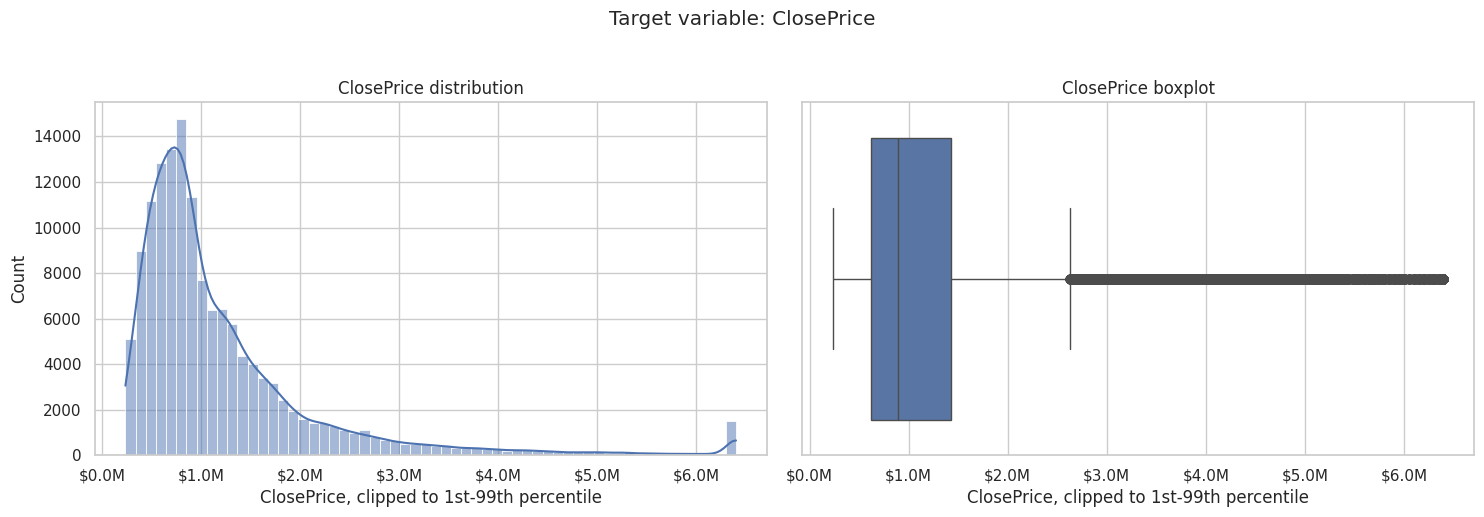

In [17]:
def clipped_series(series, lower=0.01, upper=0.99):
    clean = series.dropna()
    low, high = clean.quantile([lower, upper])
    return series.clip(lower=low, upper=high), low, high


def dollar_ticks(axis):
    axis.set_major_formatter(lambda value, pos: f"${value/1_000_000:.1f}M")


price_plot, price_p01, price_p99 = clipped_series(eda["ClosePrice"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(price_plot, bins=60, kde=True, ax=axes[0])
axes[0].set_title("ClosePrice distribution")
axes[0].set_xlabel("ClosePrice, clipped to 1st-99th percentile")
dollar_ticks(axes[0].xaxis)

sns.boxplot(x=price_plot, ax=axes[1])
axes[1].set_title("ClosePrice boxplot")
axes[1].set_xlabel("ClosePrice, clipped to 1st-99th percentile")
dollar_ticks(axes[1].xaxis)

fig.suptitle(f"Target variable: ClosePrice", y=1.03)
plt.tight_layout()
plt.show()

# Observation
The distribution of `ClosePrice` is right-skewed, with a median slightly below $1M.

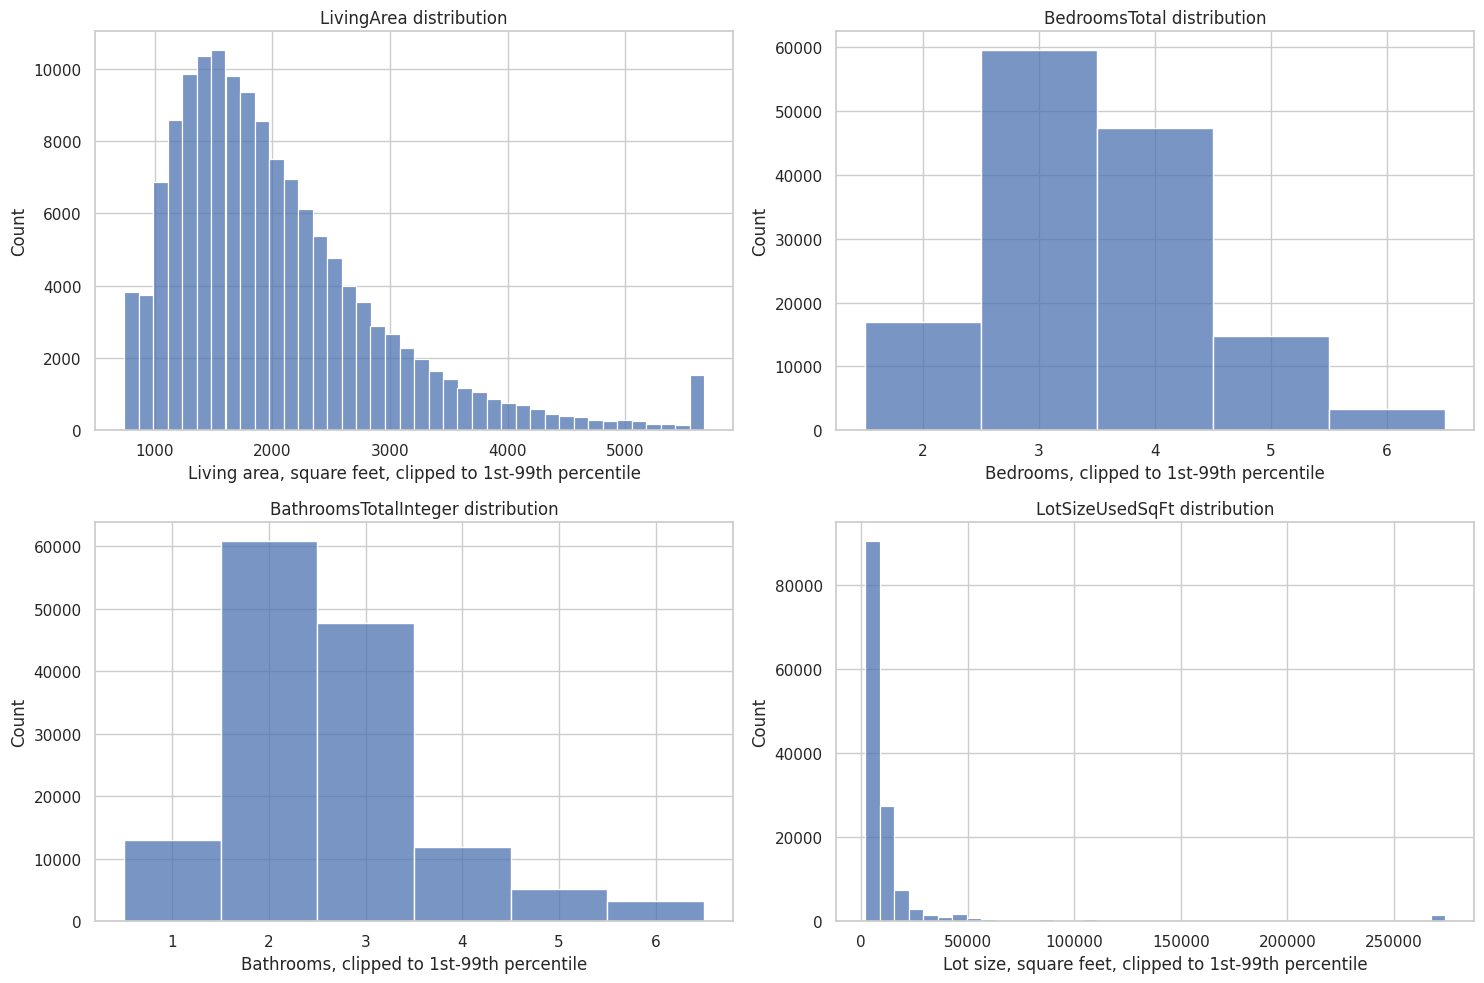

In [18]:
distribution_columns = [
    ("LivingArea", "Living area, square feet"),
    ("BedroomsTotal", "Bedrooms"),
    ("BathroomsTotalInteger", "Bathrooms"),
    ("LotSizeUsedSqFt", "Lot size, square feet"),
]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for axis, (column, label) in zip(axes, distribution_columns):
    plot_values, low, high = clipped_series(eda[column])
    bins = 40 if column in {"LivingArea", "LotSizeUsedSqFt"} else np.arange(plot_values.min(), plot_values.max() + 2) - 0.5
    sns.histplot(plot_values.dropna(), bins=bins, ax=axis)
    axis.set_title(f"{column} distribution")
    axis.set_xlabel(f"{label}, clipped to 1st-99th percentile")

plt.tight_layout()
plt.show()

# Observations
*   The distribution of `LivingArea` appears right-skewed, with a median  around 1500 sqft.
*   The distribution of `BedroomsTotal` appears unimodal and roughly symmetric. It has a mean of approx. 3.5 bedrooms.
*   The distribution of `BathroomsTotalInteger` is slightly right-skewed, with a median of approx. 2.5 bathrooms.
*   The distribution of `LotSizeUsedSqFt` is extremely right-skewed, with most SFR properties having lot sizes concentrated between the 25th percentile (5,663 sq ft) and the 75th percentile (10,454 sq ft), while having a very long tail of significantly larger parcels.





## Relationships with ClosePrice

These plots look at obvious non-leaky predictors: home size, bedrooms, bathrooms, lot size, and days on market. `ListPrice` and `OriginalListPrice` remain excluded.

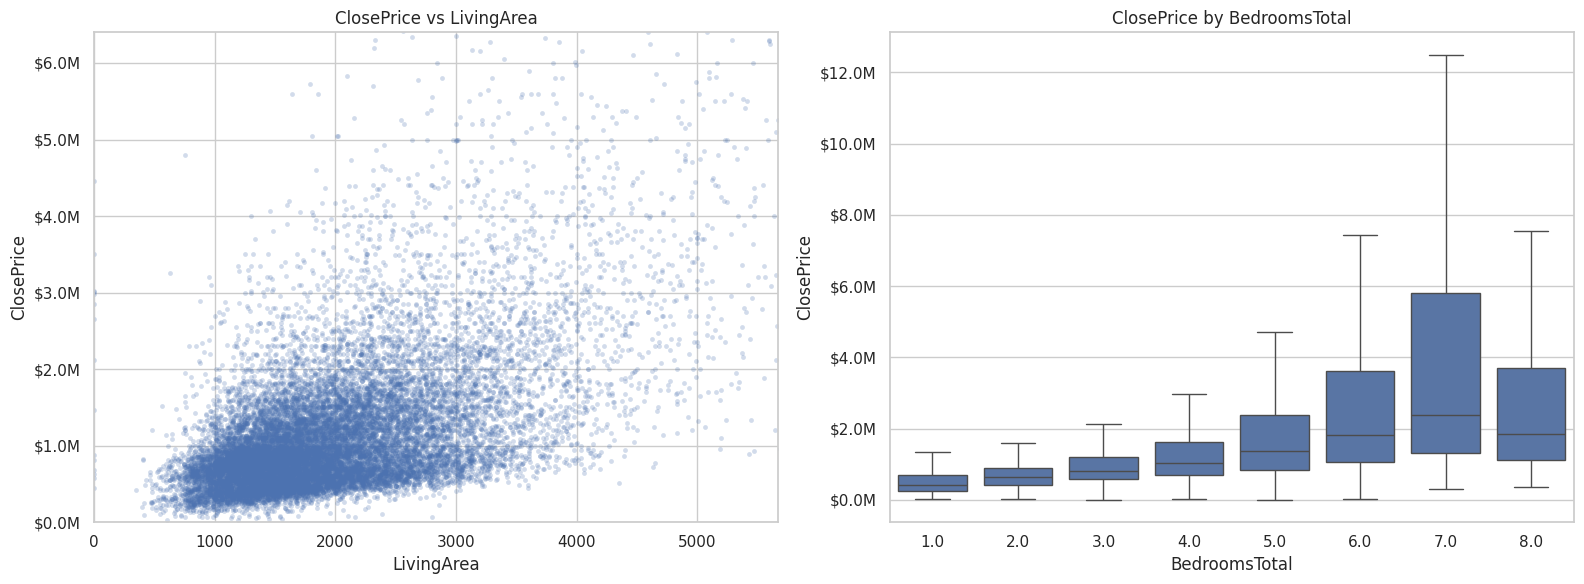

In [19]:
scatter_sample = eda.dropna(subset=["ClosePrice", "LivingArea"]).sample(
    n=min(20_000, eda.dropna(subset=["ClosePrice", "LivingArea"]).shape[0]),
    random_state=42,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(
    data=scatter_sample,
    x="LivingArea",
    y="ClosePrice",
    alpha=0.25,
    s=12,
    linewidth=0,
    ax=axes[0],
)
axes[0].set_xlim(0, eda["LivingArea"].quantile(0.99))
axes[0].set_ylim(0, eda["ClosePrice"].quantile(0.99))
axes[0].set_title("ClosePrice vs LivingArea")
axes[0].set_xlabel("LivingArea")
axes[0].set_ylabel("ClosePrice")
dollar_ticks(axes[0].yaxis)

bedroom_subset = eda.loc[eda["BedroomsTotal"].between(1, 8)]
sns.boxplot(data=bedroom_subset, x="BedroomsTotal", y="ClosePrice", showfliers=False, ax=axes[1])
axes[1].set_title("ClosePrice by BedroomsTotal")
axes[1].set_xlabel("BedroomsTotal")
axes[1].set_ylabel("ClosePrice")
dollar_ticks(axes[1].yaxis)

plt.tight_layout()
plt.show()

# Observations for `ClosePrice vs. LivingArea`

*   Positive Correlation: There is a clear, positive relationship between home size and sale price; as LivingArea increases, ClosePrice generally trends upward.

*   Heteroskedasticity (Variance Increase): The "spread" of the data points increases as LivingArea gets larger. For smaller homes, prices are relatively clustered, whereas for larger luxury homes, the price variation is significantly higher, indicating that other factors (like location, view, or lot size) play a larger role in determining the final price of large estates.

*   Density: The highest concentration of sales is clustered in the 1,000–2,500 sq ft range, suggesting this is the most active segment of the single-family residence market.

# Observations for `ClosePrice by BedroomsTotal`
*   Tiered Pricing: There is a distinct, step-wise increase in median ClosePrice as the number of bedrooms increases from 1 to 5.

*   Diminishing Returns: The price jump between 2-bedroom and 3-bedroom homes, or 3-bedroom and 4-bedroom homes, is notable. However, the price increase begins to level off or fluctuate more significantly for homes with 6+ bedrooms, likely because these properties start to fall into niche luxury categories where the number of bedrooms is less critical than the overall property size and prestige.

*   Typical Market: The bulk of the sales volume is concentrated in the 3-bedroom and 4-bedroom categories.



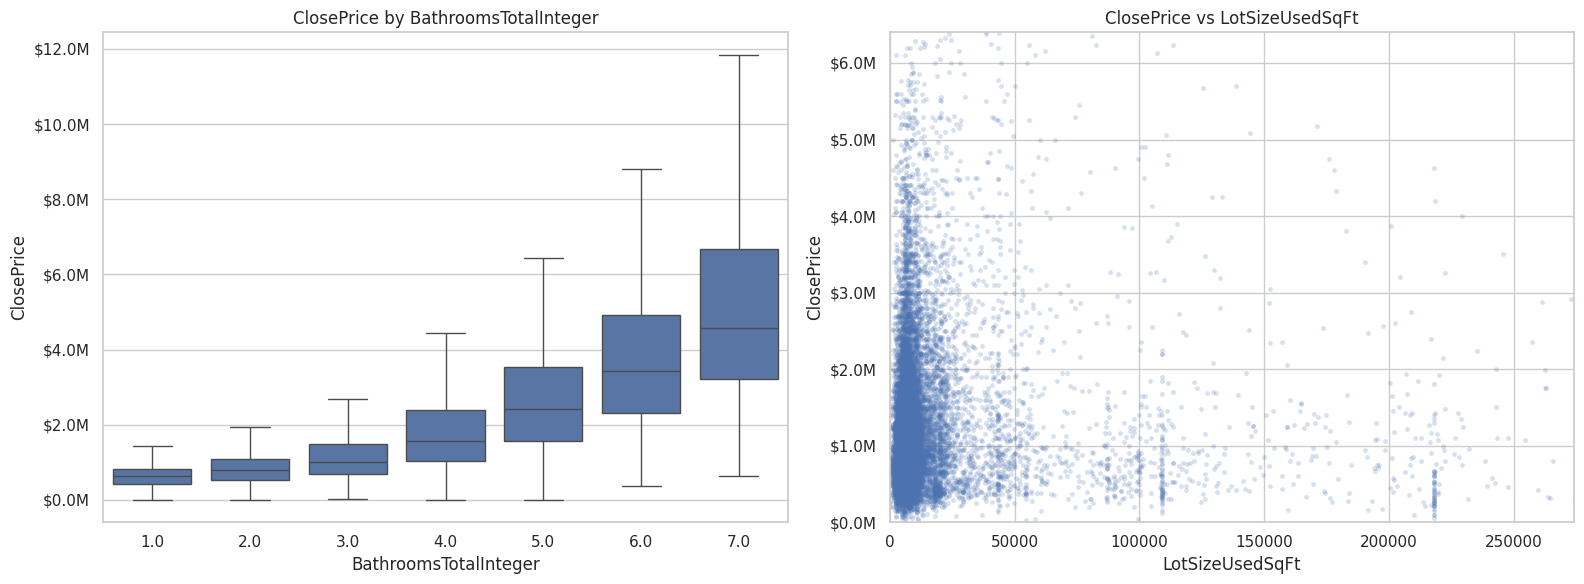

In [20]:
lot_sample = eda.dropna(subset=["ClosePrice", "LotSizeUsedSqFt"]).sample(
    n=min(20_000, eda.dropna(subset=["ClosePrice", "LotSizeUsedSqFt"]).shape[0]),
    random_state=42,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
bath_subset = eda.loc[eda["BathroomsTotalInteger"].between(1, 7)]
sns.boxplot(data=bath_subset, x="BathroomsTotalInteger", y="ClosePrice", showfliers=False, ax=axes[0])
axes[0].set_title("ClosePrice by BathroomsTotalInteger")
axes[0].set_xlabel("BathroomsTotalInteger")
axes[0].set_ylabel("ClosePrice")
dollar_ticks(axes[0].yaxis)

sns.scatterplot(
    data=lot_sample,
    x="LotSizeUsedSqFt",
    y="ClosePrice",
    alpha=0.22,
    s=12,
    linewidth=0,
    ax=axes[1],
)
axes[1].set_xlim(0, eda["LotSizeUsedSqFt"].quantile(0.99))
axes[1].set_ylim(0, eda["ClosePrice"].quantile(0.99))
axes[1].set_title("ClosePrice vs LotSizeUsedSqFt")
axes[1].set_xlabel("LotSizeUsedSqFt")
axes[1].set_ylabel("ClosePrice")
dollar_ticks(axes[1].yaxis)

plt.tight_layout()
plt.show()

# Observations for `ClosePrice by BathroomsTotalInteger`
*   Positive Price Tiering: There is a strong, consistent positive relationship between the number of bathrooms and ClosePrice. Each additional bathroom correlates with a higher median sales price, which is expected as additional bathrooms are a key driver of property value and utility.

*   Standard Configuration: The majority of properties are clustered within the 1-to-4 bathroom range. Beyond 4 bathrooms, the sample size decreases, and while the median price continues to rise, the rate of increase begins to stabilize, suggesting that after a certain point, extra bathrooms contribute less incrementally to the total price compared to other luxury features.

# Observations for `ClosePrice vs. LotSizeUsedSqFt`
*   High Variability: Unlike LivingArea, the relationship between LotSizeUsedSqFt and ClosePrice is much more dispersed. While there is a general trend where larger lots can command higher prices, there is significant overlap and high variance across all lot sizes.

*   Market Segmentation: The plot shows a dense concentration of sales for properties with lot sizes under 20,000 sq ft. For these properties, the lot size seems to be a secondary factor to the home itself. The wider dispersion at higher lot sizes likely reflects that very large parcels are often sold as "land value" or estate properties, where the location and potential for development weigh more heavily on the price than the exact square footage of the lot alone.

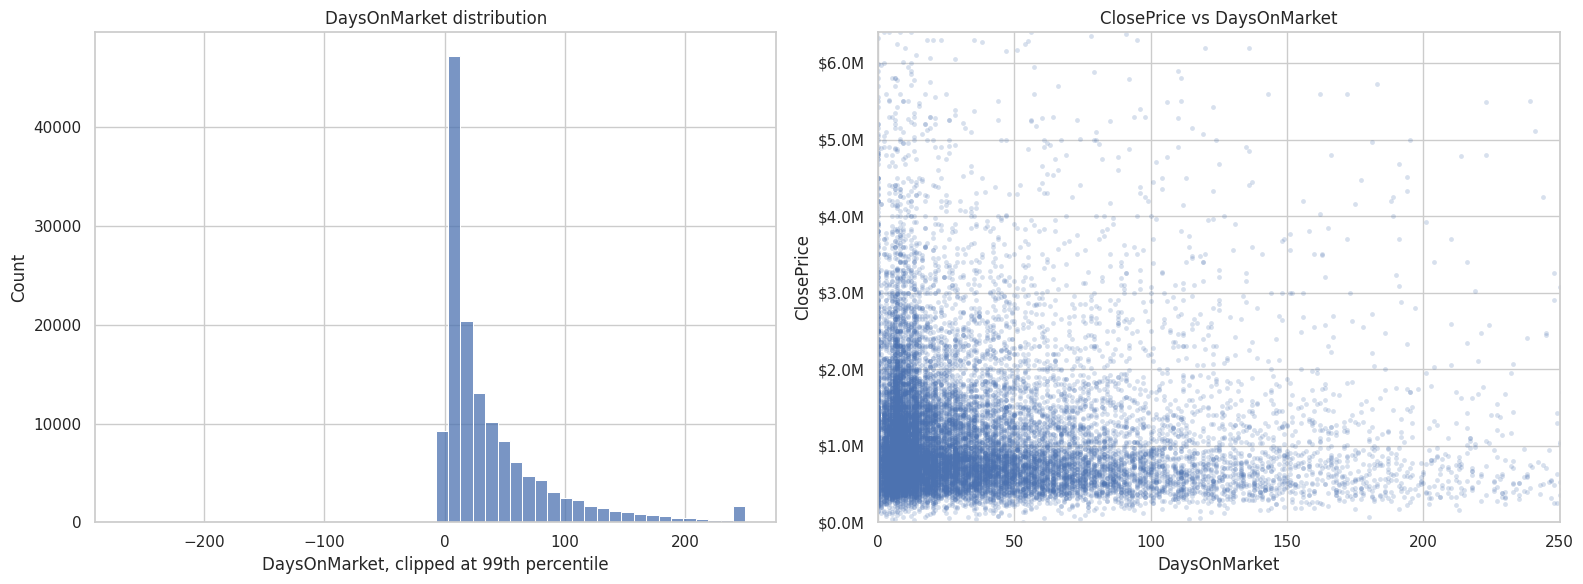

In [21]:
dom_sample = eda.dropna(subset=["ClosePrice", "DaysOnMarket"]).sample(
    n=min(20_000, eda.dropna(subset=["ClosePrice", "DaysOnMarket"]).shape[0]),
    random_state=42,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(eda["DaysOnMarket"].clip(upper=eda["DaysOnMarket"].quantile(0.99)), bins=50, ax=axes[0])
axes[0].set_title("DaysOnMarket distribution")
axes[0].set_xlabel("DaysOnMarket, clipped at 99th percentile")

sns.scatterplot(data=dom_sample, x="DaysOnMarket", y="ClosePrice", alpha=0.22, s=12, linewidth=0, ax=axes[1])
axes[1].set_xlim(0, eda["DaysOnMarket"].quantile(0.99))
axes[1].set_ylim(0, eda["ClosePrice"].quantile(0.99))
axes[1].set_title("ClosePrice vs DaysOnMarket")
axes[1].set_xlabel("DaysOnMarket")
axes[1].set_ylabel("ClosePrice")
dollar_ticks(axes[1].yaxis)

plt.tight_layout()
plt.show()

## Monthly close-price and volume trends

The primer emphasizes that sold records should be used for price and volume analysis. The monthly view checks whether the one-year window has obvious seasonality or shifts.

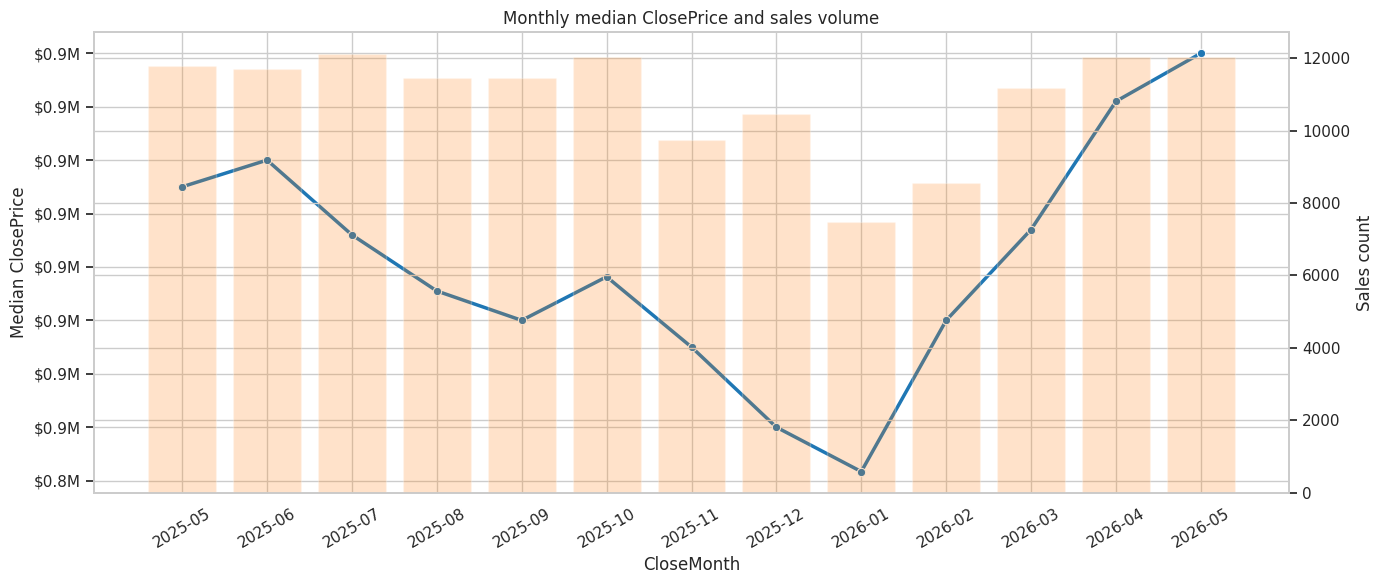

,CloseMonth,sales,median_close_price,mean_close_price,median_living_area,median_days_on_market
0,2025-05,11777,"905,000.00","1,333,889.29","1,815.00",15.00
1,2025-06,11701,"910,000.00","1,372,108.93","1,836.00",18.00
2,2025-07,12113,"896,000.00","1,313,768.73","1,812.00",20.00
3,2025-08,11454,"885,500.00","1,237,614.44","1,806.00",23.00
4,2025-09,11456,"880,000.00","1,508,458.33","1,806.00",23.00
5,2025-10,12029,"888,163.00","1,333,730.14","1,824.00",24.00
6,2025-11,9739,"875,000.00","1,338,764.04","1,812.00",24.00
7,2025-12,10455,"860,000.00","1,195,244.05","1,804.00",26.00
8,2026-01,7490,"851,691.50","1,280,368.97","1,821.00",30.00
9,2026-02,8550,"880,000.00","1,393,256.18","1,820.00",21.00


In [22]:
monthly = (
    eda.groupby("CloseMonth", observed=True)
    .agg(
        sales=("ListingKey", "size"),
        median_close_price=("ClosePrice", "median"),
        mean_close_price=("ClosePrice", "mean"),
        median_living_area=("LivingArea", "median"),
        median_days_on_market=("DaysOnMarket", "median"),
    )
    .reset_index()
    .sort_values("CloseMonth")
)

fig, axis_price = plt.subplots(figsize=(14, 6))
axis_volume = axis_price.twinx()

sns.lineplot(data=monthly, x="CloseMonth", y="median_close_price", marker="o", linewidth=2.5, ax=axis_price, color="#1f77b4")
axis_volume.bar(monthly["CloseMonth"], monthly["sales"], alpha=0.22, color="#ff7f0e", label="Sales")

axis_price.set_title("Monthly median ClosePrice and sales volume")
axis_price.set_xlabel("CloseMonth")
axis_price.set_ylabel("Median ClosePrice")
axis_volume.set_ylabel("Sales count")
dollar_ticks(axis_price.yaxis)

for tick in axis_price.get_xticklabels():
    tick.set_rotation(30)

plt.tight_layout()
plt.show()
display(monthly)

## Location checks

Location is central to real estate pricing. These plots summarize county-level volume/median prices and show the geographic spread of records with usable coordinates.

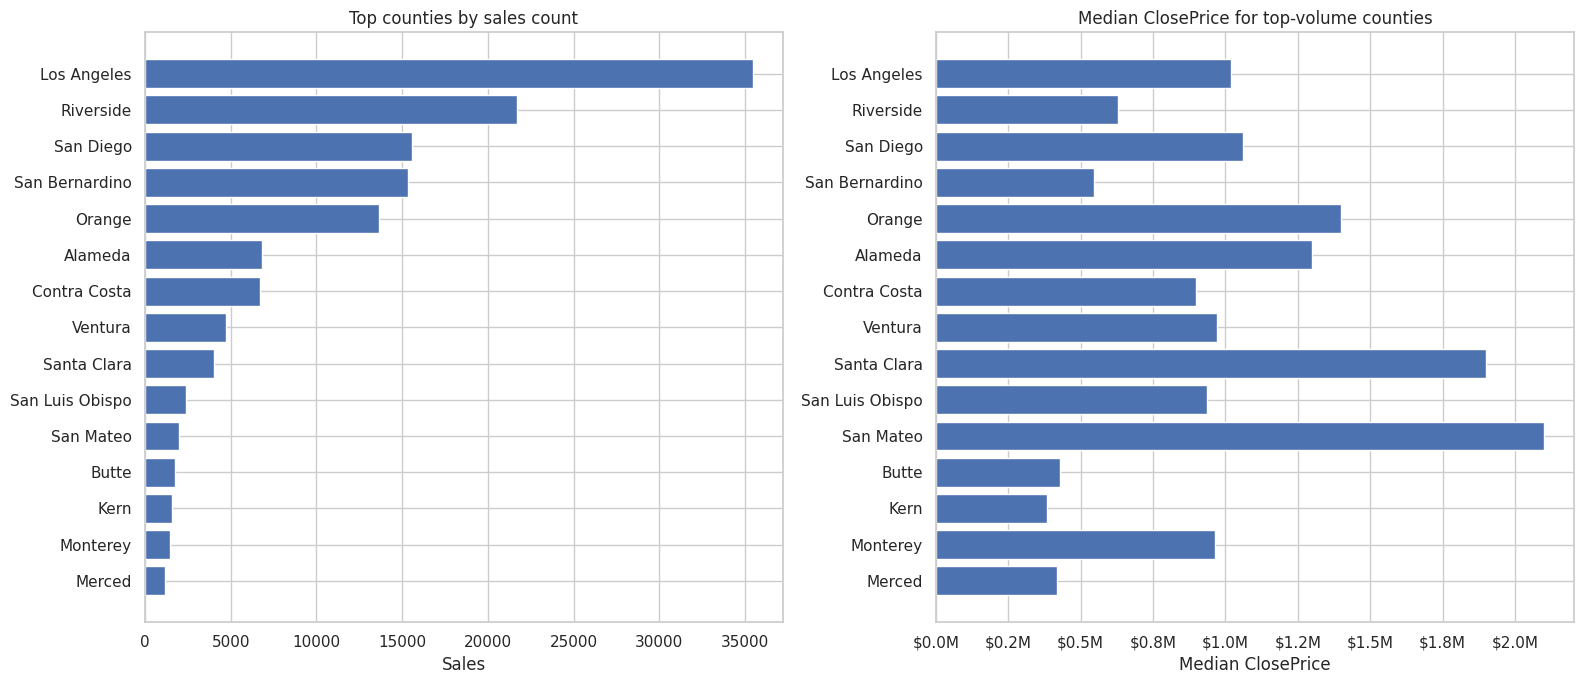

,sales,median_close_price,median_living_area
CountyOrParish,,,
Los Angeles,35439,"1,018,000.00","1,730.00"
Riverside,21672,"630,000.00","2,005.00"
San Diego,15559,"1,060,000.00","1,875.00"
San Bernardino,15363,"546,000.00","1,684.00"
Orange,13658,"1,400,000.00","2,013.00"
Alameda,6818,"1,300,000.00","1,702.50"
Contra Costa,6724,"899,475.00","1,957.50"
Ventura,4699,"970,000.00","1,927.00"
Santa Clara,4044,"1,900,000.00","1,797.00"


In [23]:
county_summary = (
    eda.groupby("CountyOrParish", observed=True)
    .agg(
        sales=("ListingKey", "size"),
        median_close_price=("ClosePrice", "median"),
        median_living_area=("LivingArea", "median"),
    )
    .dropna()
    .sort_values("sales", ascending=False)
)

top_counties = county_summary.head(15).sort_values("sales")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(top_counties.index, top_counties["sales"])
axes[0].set_title("Top counties by sales count")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("")

axes[1].barh(top_counties.index, top_counties["median_close_price"])
axes[1].set_title("Median ClosePrice for top-volume counties")
axes[1].set_xlabel("Median ClosePrice")
axes[1].set_ylabel("")
dollar_ticks(axes[1].xaxis)

plt.tight_layout()
plt.show()
display(county_summary.head(15))

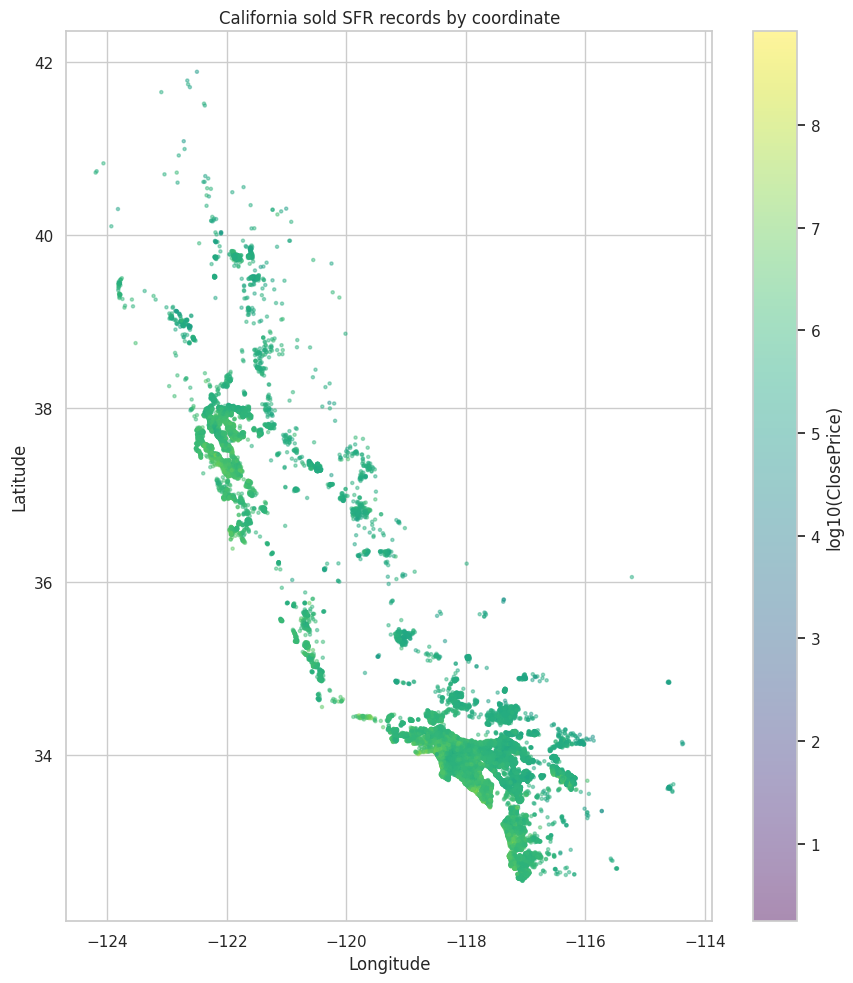

In [24]:
geo = eda.dropna(subset=["Latitude", "Longitude", "ClosePrice"]).copy()
geo = geo.loc[
    geo["Latitude"].between(32, 42.5)
    & geo["Longitude"].between(-125, -113)
]
geo_sample = geo.sample(n=min(30_000, len(geo)), random_state=42)

fig, axis = plt.subplots(figsize=(9, 10))
scatter = axis.scatter(
    geo_sample["Longitude"],
    geo_sample["Latitude"],
    c=np.log10(geo_sample["ClosePrice"]),
    cmap="viridis",
    s=5,
    alpha=0.45,
)
axis.set_title("California sold SFR records by coordinate")
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")
colorbar = plt.colorbar(scatter, ax=axis)
colorbar.set_label("log10(ClosePrice)")
plt.tight_layout()
plt.show()

## Correlation heatmap

The correlation matrix includes `ClosePrice` plus non-leaky numeric feature candidates. It intentionally omits `ListPrice` and `OriginalListPrice`.

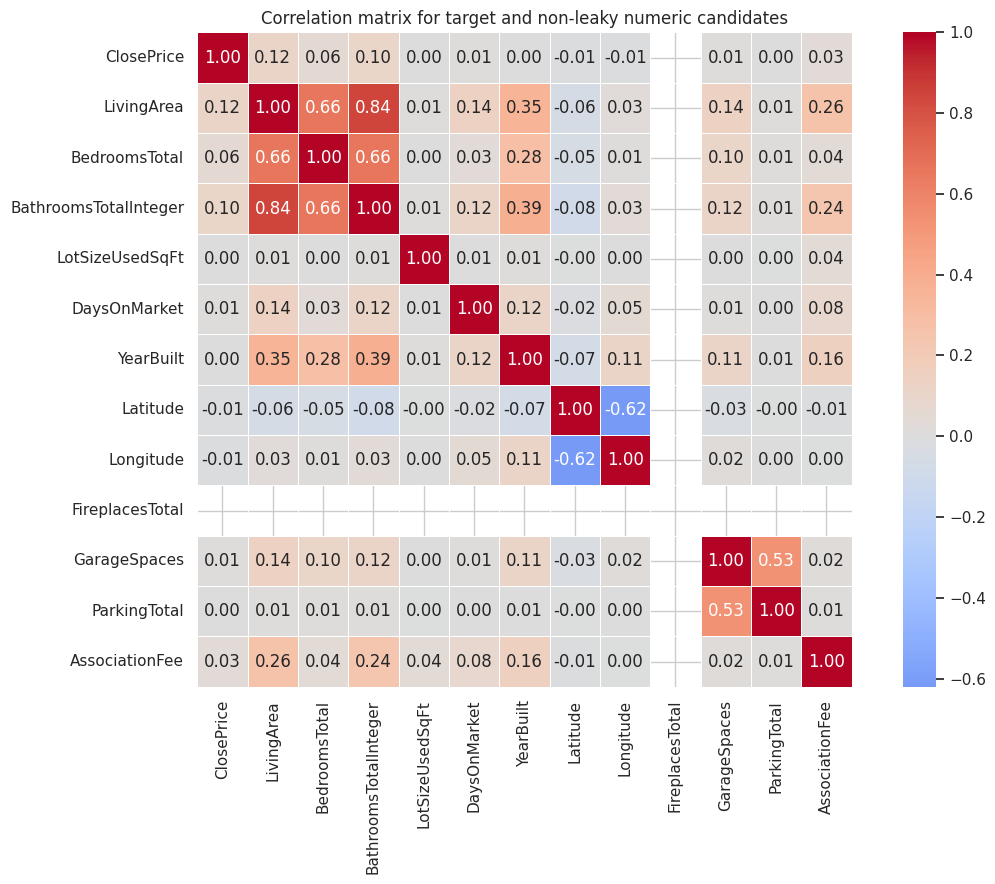

In [25]:
correlation_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeUsedSqFt",
    "DaysOnMarket",
    "YearBuilt",
    "Latitude",
    "Longitude",
    "FireplacesTotal",
    "GarageSpaces",
    "ParkingTotal",
    "AssociationFee",
]

corr = eda[correlation_columns].corr(numeric_only=True)

fig, axis = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=axis)
axis.set_title("Correlation matrix for target and non-leaky numeric candidates")
plt.tight_layout()
plt.show()

## Candidate feature list for future notebooks

Week 3 will handle preprocessing and train/test splitting. This Week 2 notebook records a starter set of non-leaky feature candidates only.

In [26]:
candidate_feature_table = pd.DataFrame({"candidate_feature": MODEL_FEATURE_CANDIDATES})
display(candidate_feature_table)

display(
    Markdown(
        f'''
## Week 2 EDA takeaways

- Loaded **{len(DATA_FILES)}** monthly CRMLS sold files from **{actual_months[0]}** through **{actual_months[-1]}**.
- Started with **{len(raw):,}** sold records and retained **{len(eda):,}** Residential + SingleFamilyResidence records with valid `ClosePrice`.
- Median `ClosePrice` for the filtered EDA set is **${eda["ClosePrice"].median():,.0f}**.
- Median `LivingArea` is **{eda["LivingArea"].median():,.0f} sq ft**, median bedrooms is **{eda["BedroomsTotal"].median():.0f}**, median bathrooms is **{eda["BathroomsTotalInteger"].median():.0f}**, and median lot size is **{eda["LotSizeUsedSqFt"].median():,.0f} sq ft**.
- `LivingArea`, bathrooms, bedrooms, location, and several amenity/property fields are useful candidates for Week 3 preprocessing.
- `ListPrice` and `OriginalListPrice` are not included in the feature candidate list.
'''
    )
)

,candidate_feature
0,LivingArea
1,BedroomsTotal
2,BathroomsTotalInteger
3,LotSizeUsedSqFt
4,DaysOnMarket
5,YearBuilt
6,Latitude
7,Longitude
8,FireplacesTotal
9,GarageSpaces



## Week 2 EDA takeaways

- Loaded **13** monthly CRMLS sold files from **202505** through **202605**.
- Started with **281,823** sold records and retained **141,996** Residential + SingleFamilyResidence records with valid `ClosePrice`.
- Median `ClosePrice` for the filtered EDA set is **$890,000**.
- Median `LivingArea` is **1,820 sq ft**, median bedrooms is **3**, median bathrooms is **2**, and median lot size is **7,290 sq ft**.
- `LivingArea`, bathrooms, bedrooms, location, and several amenity/property fields are useful candidates for Week 3 preprocessing.
- `ListPrice` and `OriginalListPrice` are not included in the feature candidate list.
